In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

## Задание 1. Загрузка изображения в оттенках серого

Форма изображения: (675, 1200) | тип данных: uint8
Мин. яркость: 0 | макс. яркость: 255 | средняя яркость: 78.24


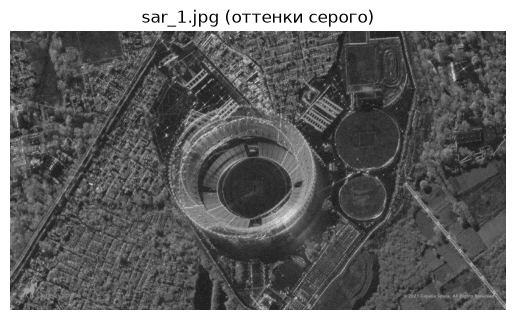

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print('Форма изображения:', image_gray.shape, '| тип данных:', image_gray.dtype)
print('Мин. яркость:', image_gray.min(), '| макс. яркость:', image_gray.max(),
      '| средняя яркость:', round(image_gray.mean(), 2))

plt.imshow(image_gray, cmap='gray')
plt.title('sar_1.jpg (оттенки серого)')
plt.axis('off')
plt.show()

## Задание 2. Наложение шума Гаусса

Аддитивная модель шума: $g = f + n$, где $n$ имеет нормальное распределение с плотностью
$p(z) = \dfrac{1}{\sqrt{2\pi}\,\sigma}\,e^{-(z-\mu)^2 / 2\sigma^2}$.

Параметры: $\mu = 0$, $\sigma = 25$ (умеренный шум, изображение ещё читается).
Шум генерируем в float и прибавляем к float-копии изображения: если генерировать сразу
в uint8 (как `cv2.randn` по массиву uint8), отрицательные значения обрежутся до нуля,
и шум получится односторонним.

In [3]:
mean = 0
stddev = 25
noise_gauss = np.random.normal(mean, stddev, image_gray.shape).astype(np.float32)

# прибавляем шум к float-копии и обрезаем результат в [0, 255]
image_noise_gauss = np.clip(image_gray.astype(np.float32) + noise_gauss, 0, 255).astype(np.uint8)

mse_noise_gauss = mean_squared_error(image_gray, image_noise_gauss)
ssim_noise_gauss = structural_similarity(image_gray, image_noise_gauss)
print('Шум Гаусса (sigma = %d): MSE = %.1f, SSIM = %.4f' % (stddev, mse_noise_gauss, ssim_noise_gauss))

Шум Гаусса (sigma = 25): MSE = 610.6, SSIM = 0.4805


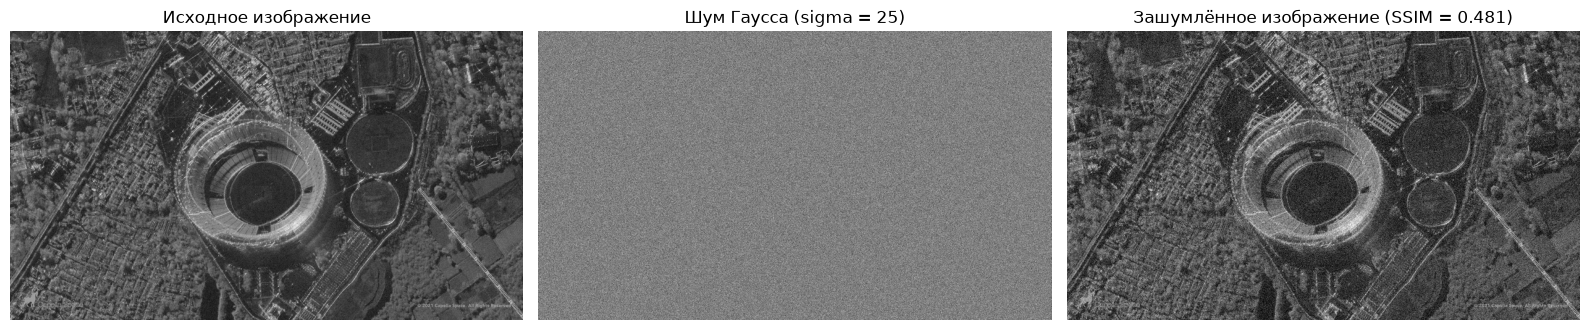

In [4]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Шум Гаусса (sigma = 25)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_noise_gauss, cmap='gray')
plt.title('Зашумлённое изображение (SSIM = %.3f)' % ssim_noise_gauss)
plt.axis('off')

plt.tight_layout()
plt.show()

## Задание 3. Наложение постоянного (равномерного) шума

Постоянный шум имеет постоянную плотность вероятности на отрезке $[a, b]$ (по лекции):
$p(z) = \dfrac{1}{b-a}$ при $a \le z \le b$, иначе $0$; матожидание $\dfrac{a+b}{2}$,
дисперсия $\dfrac{(b-a)^2}{12}$.

Параметры: $a = -50$, $b = 50$. Дисперсия получается $\approx 833$, примерно как у шума
Гаусса с $\sigma = 25$, но характер шума другой.

In [5]:
a, b = -50, 50
noise_unif = np.random.uniform(a, b, image_gray.shape).astype(np.float32)

# прибавляем к float-копии и обрезаем в [0, 255]
image_noise_unif = np.clip(image_gray.astype(np.float32) + noise_unif, 0, 255).astype(np.uint8)

mse_noise_unif = mean_squared_error(image_gray, image_noise_unif)
ssim_noise_unif = structural_similarity(image_gray, image_noise_unif)
print('Постоянный шум (U[%d, %d]): MSE = %.1f, SSIM = %.4f' % (a, b, mse_noise_unif, ssim_noise_unif))

Постоянный шум (U[-50, 50]): MSE = 822.4, SSIM = 0.4155


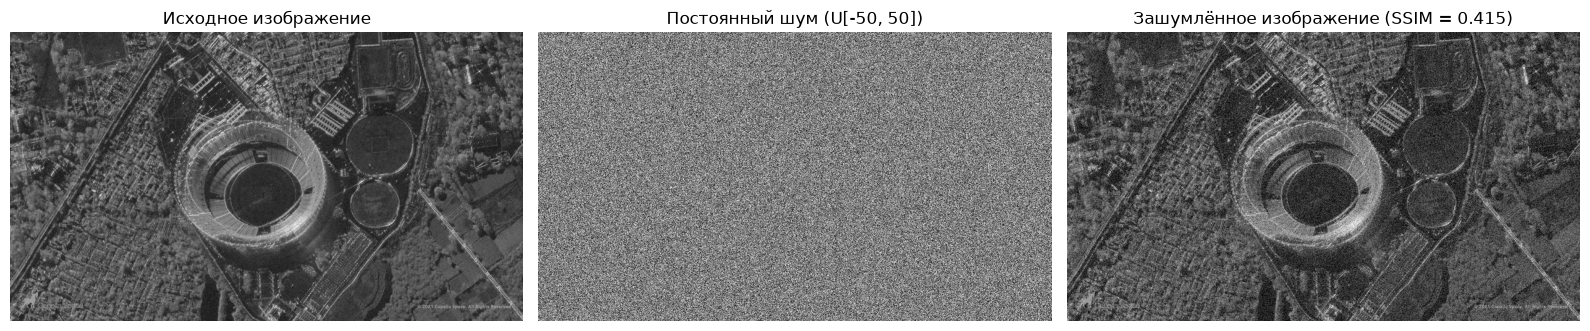

In [6]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noise_unif, cmap='gray')
plt.title('Постоянный шум (U[-50, 50])')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_noise_unif, cmap='gray')
plt.title('Зашумлённое изображение (SSIM = %.3f)' % ssim_noise_unif)
plt.axis('off')

plt.tight_layout()
plt.show()

## Задание 4. Медианный фильтр (cv2.medianBlur)

Нелинейный фильтр: значение пикселя заменяется медианой значений в окне $k \times k$.
Лучше всего убирает импульсный шум («соль-перец»). Проверяем окна $k = 3, 5, 7, 9$.

In [7]:
results = []   # (тип шума, название фильтра с параметрами, MSE, SSIM)
images = {}     # (тип шума, название фильтра) -> отфильтрованное изображение

def add_result(noise_name, filter_name, img_filtered):
    # считает метрики относительно исходного изображения и запоминает результат
    mse = mean_squared_error(image_gray, img_filtered)
    ssim = structural_similarity(image_gray, img_filtered)
    results.append((noise_name, filter_name, mse, ssim))
    images[(noise_name, filter_name)] = img_filtered
    print('%-15s | %-34s MSE = %7.1f   SSIM = %.4f' % (noise_name, filter_name, mse, ssim))

def plot_grid(res_gauss, res_unif, suptitle):
    # сетка результатов: сверху шум Гаусса, снизу постоянный шум
    names = list(res_gauss.keys())
    plt.figure(figsize=(4 * len(names), 7.5))
    for row, (res, noise_name) in enumerate([(res_gauss, 'Шум Гаусса'),
                                              (res_unif, 'Постоянный шум')]):
        for col, name in enumerate(names):
            img = res[name]
            mse = mean_squared_error(image_gray, img)
            ssim = structural_similarity(image_gray, img)
            plt.subplot(2, len(names), row * len(names) + col + 1)
            plt.imshow(img, cmap='gray')
            plt.title('%s\n%s: MSE = %.0f, SSIM = %.3f' % (noise_name, name, mse, ssim), fontsize=9)
            plt.axis('off')
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

In [8]:
median_gauss = {}
median_unif = {}

for k in [3, 5, 7, 9]:
    median_gauss['k = %d' % k] = cv2.medianBlur(image_noise_gauss, k)
    median_unif['k = %d' % k] = cv2.medianBlur(image_noise_unif, k)

for name, res in median_gauss.items():
    add_result('Шум Гаусса', 'Медианный (%s)' % name, res)
for name, res in median_unif.items():
    add_result('Постоянный шум', 'Медианный (%s)' % name, res)

Шум Гаусса      | Медианный (k = 3)                  MSE =   209.6   SSIM = 0.6378
Шум Гаусса      | Медианный (k = 5)                  MSE =   240.5   SSIM = 0.5610
Шум Гаусса      | Медианный (k = 7)                  MSE =   286.3   SSIM = 0.4824
Шум Гаусса      | Медианный (k = 9)                  MSE =   331.4   SSIM = 0.4148
Постоянный шум  | Медианный (k = 3)                  MSE =   311.5   SSIM = 0.5428
Постоянный шум  | Медианный (k = 5)                  MSE =   283.8   SSIM = 0.5101
Постоянный шум  | Медианный (k = 7)                  MSE =   310.0   SSIM = 0.4545
Постоянный шум  | Медианный (k = 9)                  MSE =   347.1   SSIM = 0.3963


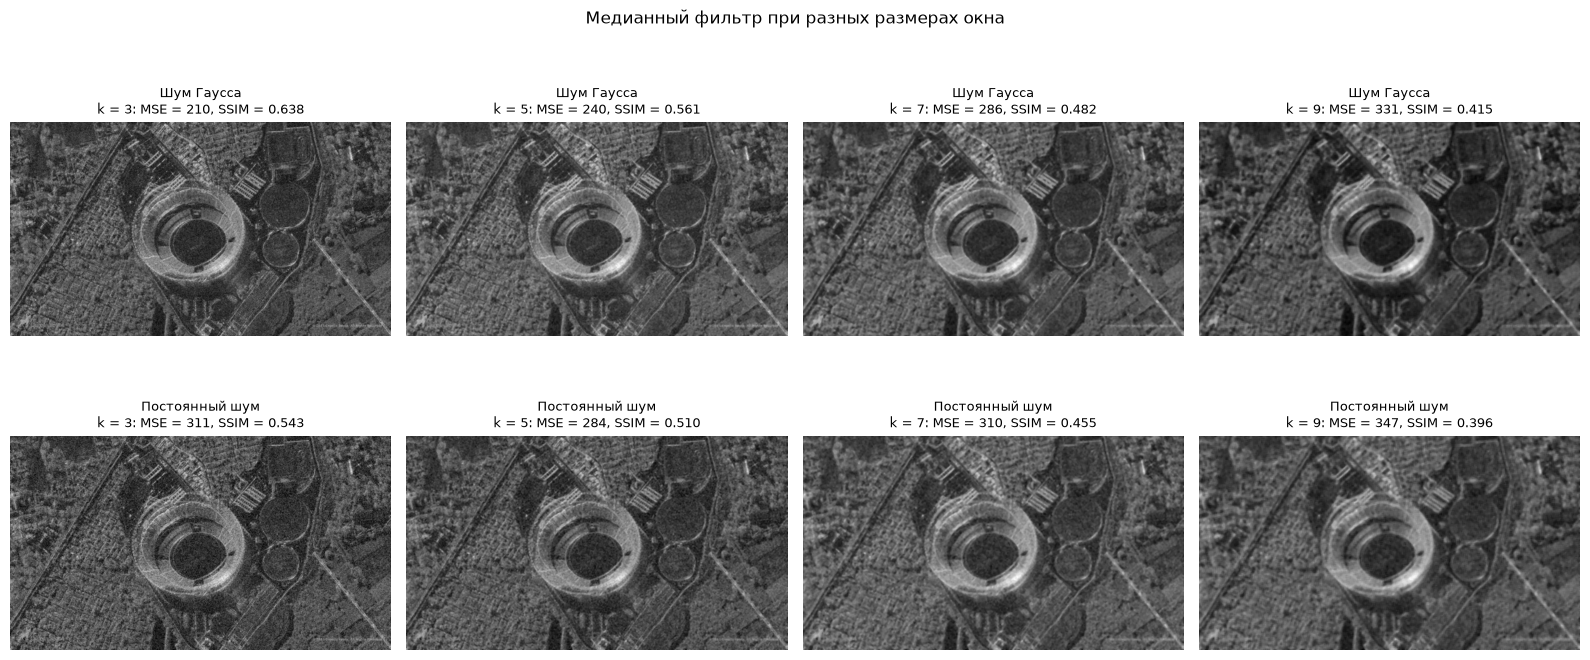

In [9]:
plot_grid(median_gauss, median_unif, 'Медианный фильтр при разных размерах окна')

## Задание 5. Фильтр Гаусса (cv2.GaussianBlur)

Линейный свёрточный фильтр: свёртка с ядром Гаусса размера $k \times k$ (при `sigmaX = 0`
$\sigma$ подбирается автоматически по размеру ядра). Сглаживает и шум, и сами детали:
чем больше ядро, тем сильнее размытие краёв. Проверяем ядра $k = 3, 5, 7, 9$.

In [10]:
gauss_gauss = {}
gauss_unif = {}

for k in [3, 5, 7, 9]:
    gauss_gauss['k = %d' % k] = cv2.GaussianBlur(image_noise_gauss, (k, k), 0)
    gauss_unif['k = %d' % k] = cv2.GaussianBlur(image_noise_unif, (k, k), 0)

for name, res in gauss_gauss.items():
    add_result('Шум Гаусса', 'Фильтр Гаусса (%s)' % name, res)
for name, res in gauss_unif.items():
    add_result('Постоянный шум', 'Фильтр Гаусса (%s)' % name, res)

Шум Гаусса      | Фильтр Гаусса (k = 3)              MSE =   149.7   SSIM = 0.7245
Шум Гаусса      | Фильтр Гаусса (k = 5)              MSE =   156.3   SSIM = 0.7066
Шум Гаусса      | Фильтр Гаусса (k = 7)              MSE =   188.7   SSIM = 0.6480
Шум Гаусса      | Фильтр Гаусса (k = 9)              MSE =   214.6   SSIM = 0.6019
Постоянный шум  | Фильтр Гаусса (k = 3)              MSE =   180.3   SSIM = 0.6850
Постоянный шум  | Фильтр Гаусса (k = 5)              MSE =   172.5   SSIM = 0.6827
Постоянный шум  | Фильтр Гаусса (k = 7)              MSE =   197.1   SSIM = 0.6361
Постоянный шум  | Фильтр Гаусса (k = 9)              MSE =   220.2   SSIM = 0.5947


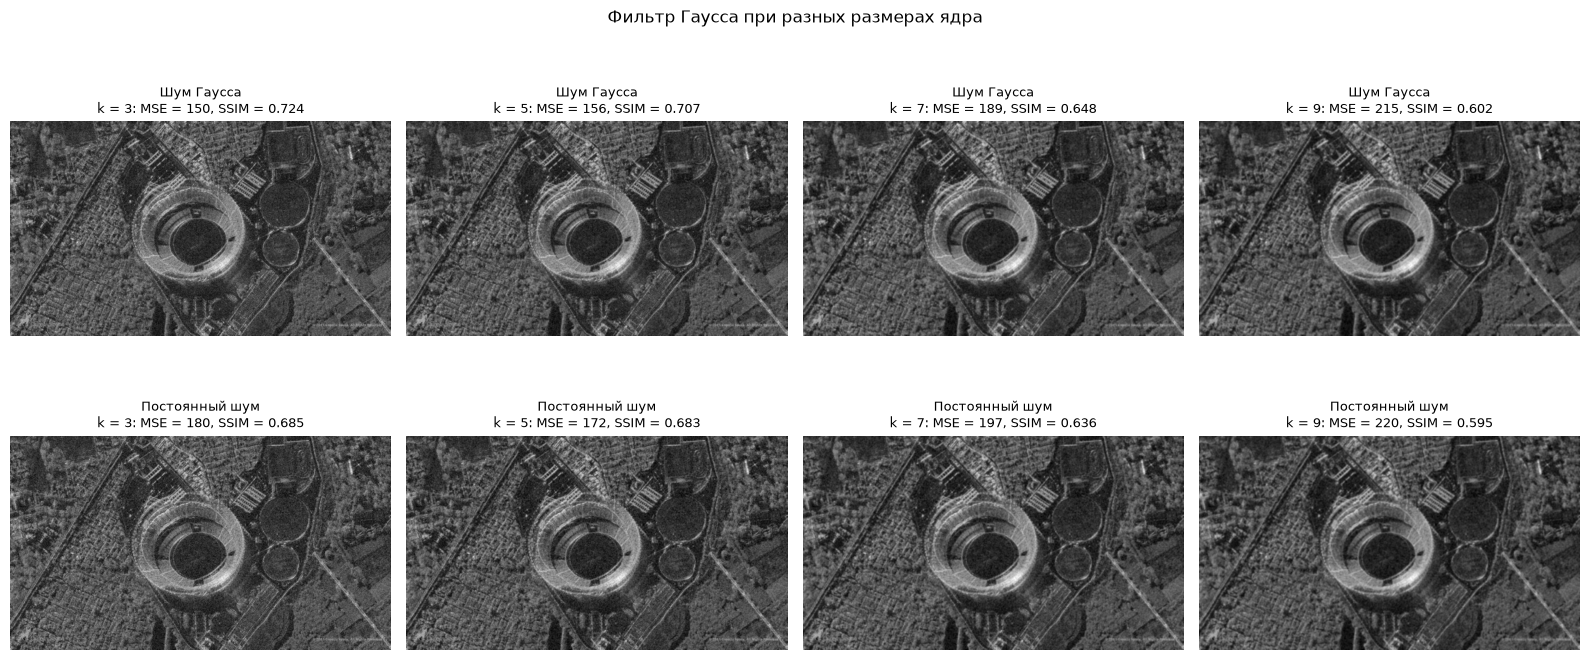

In [11]:
plot_grid(gauss_gauss, gauss_unif, 'Фильтр Гаусса при разных размерах ядра')

## Задание 6. Билатериальный фильтр (cv2.bilateralFilter)

Усредняет пиксели с двумя весами: по расстоянию ($\sigma_{space}$) и по разнице яркостей
($\sigma_{color}$). Пиксели с заметно другой яркостью (края) почти не участвуют в
усреднении, поэтому края должны сохраняться. Проверяем $(d, \sigma)$: (5, 25), (5, 50),
(9, 75) как на практике, (9, 150).

In [12]:
bilat_gauss = {}
bilat_unif = {}

bilat_params = [(5, 25, 25), (5, 50, 50), (9, 75, 75), (9, 150, 150)]
for d, sigma_color, sigma_space in bilat_params:
    name = 'd = %d, sigma = %d' % (d, sigma_color)
    bilat_gauss[name] = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
    bilat_unif[name] = cv2.bilateralFilter(image_noise_unif, d, sigma_color, sigma_space)

for name, res in bilat_gauss.items():
    add_result('Шум Гаусса', 'Билатериальный (%s)' % name, res)
for name, res in bilat_unif.items():
    add_result('Постоянный шум', 'Билатериальный (%s)' % name, res)

Шум Гаусса      | Билатериальный (d = 5, sigma = 25) MSE =   302.9   SSIM = 0.6029
Шум Гаусса      | Билатериальный (d = 5, sigma = 50) MSE =   162.6   SSIM = 0.7036
Шум Гаусса      | Билатериальный (d = 9, sigma = 75) MSE =   201.7   SSIM = 0.6127
Шум Гаусса      | Билатериальный (d = 9, sigma = 150) MSE =   253.1   SSIM = 0.5281
Постоянный шум  | Билатериальный (d = 5, sigma = 25) MSE =   478.4   SSIM = 0.5054
Постоянный шум  | Билатериальный (d = 5, sigma = 50) MSE =   220.4   SSIM = 0.6428
Постоянный шум  | Билатериальный (d = 9, sigma = 75) MSE =   209.0   SSIM = 0.6102
Постоянный шум  | Билатериальный (d = 9, sigma = 150) MSE =   254.4   SSIM = 0.5305


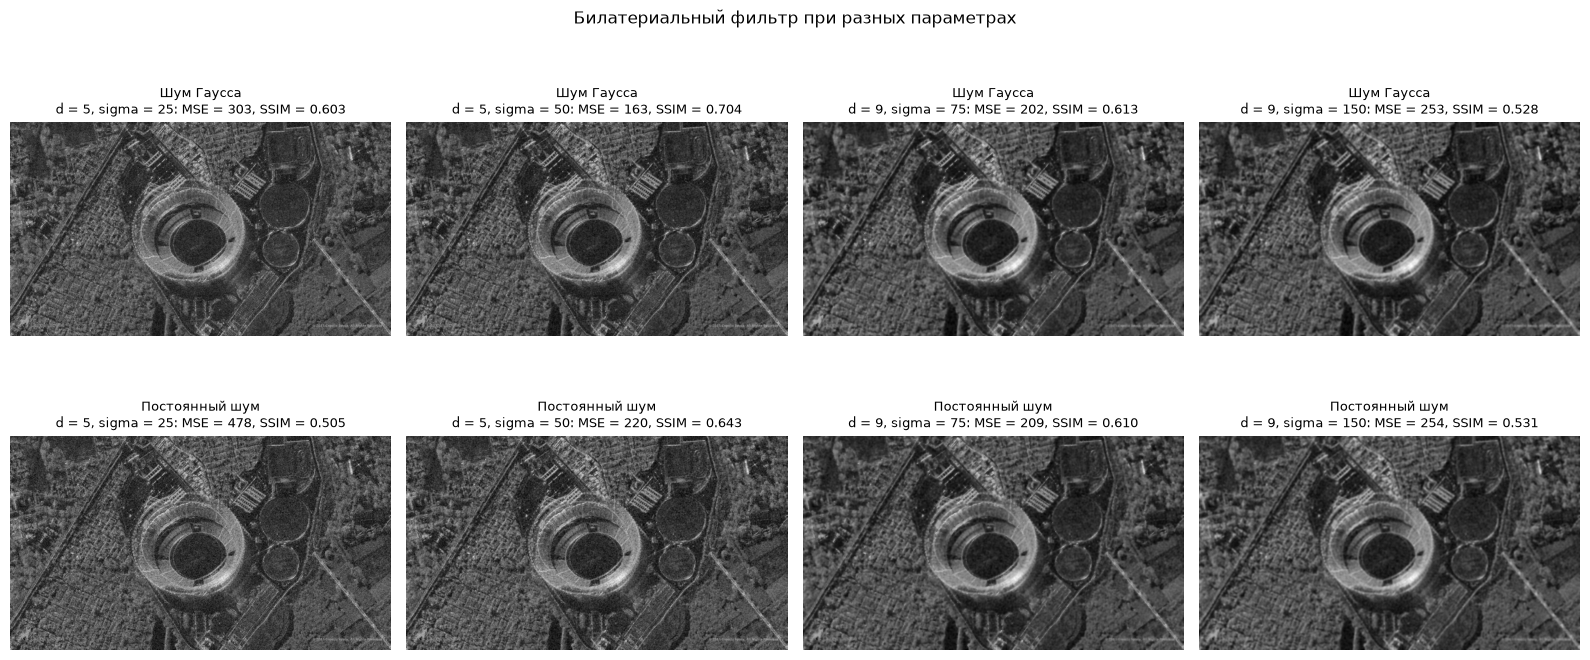

In [13]:
plot_grid(bilat_gauss, bilat_unif, 'Билатериальный фильтр при разных параметрах')

## Задание 7. Фильтр нелокальных средних (cv2.fastNlMeansDenoising)

По лекции: вес пикселя $q$ при усреднении значения в пикселе $p$ зависит от близости целых
окрестностей (блоков), а не отдельных пикселей:

$u(p) = \dfrac{\sum_q w(p, q)\, v(q)}{\sum_q w(p, q)}, \qquad
w(p, q) = \exp\!\left(-\dfrac{\max\bigl(\|B(p, q)\|^2 - 2\sigma^2,\; 0\bigr)}{h^2}\right)$

Главный параметр $h$: при маленьком $h$ фильтр почти не действует, при большом замыливает
детали. Проверяем $h = 10, 15, 20, 30$ (размер шаблона и окна поиска стандартные: 7 и 21).

In [14]:
nlm_gauss = {}
nlm_unif = {}

for h in [10, 15, 20, 30]:
    nlm_gauss['h = %d' % h] = cv2.fastNlMeansDenoising(image_noise_gauss, None, h)
    nlm_unif['h = %d' % h] = cv2.fastNlMeansDenoising(image_noise_unif, None, h)

for name, res in nlm_gauss.items():
    add_result('Шум Гаусса', 'Нелокальных средних (%s)' % name, res)
for name, res in nlm_unif.items():
    add_result('Постоянный шум', 'Нелокальных средних (%s)' % name, res)

Шум Гаусса      | Нелокальных средних (h = 10)       MSE =   610.5   SSIM = 0.4805
Шум Гаусса      | Нелокальных средних (h = 15)       MSE =   420.1   SSIM = 0.5590
Шум Гаусса      | Нелокальных средних (h = 20)       MSE =   182.1   SSIM = 0.6653
Шум Гаусса      | Нелокальных средних (h = 30)       MSE =   259.8   SSIM = 0.5047
Постоянный шум  | Нелокальных средних (h = 10)       MSE =   822.4   SSIM = 0.4155
Постоянный шум  | Нелокальных средних (h = 15)       MSE =   753.5   SSIM = 0.4287
Постоянный шум  | Нелокальных средних (h = 20)       MSE =   281.8   SSIM = 0.6128
Постоянный шум  | Нелокальных средних (h = 30)       MSE =   250.2   SSIM = 0.5232


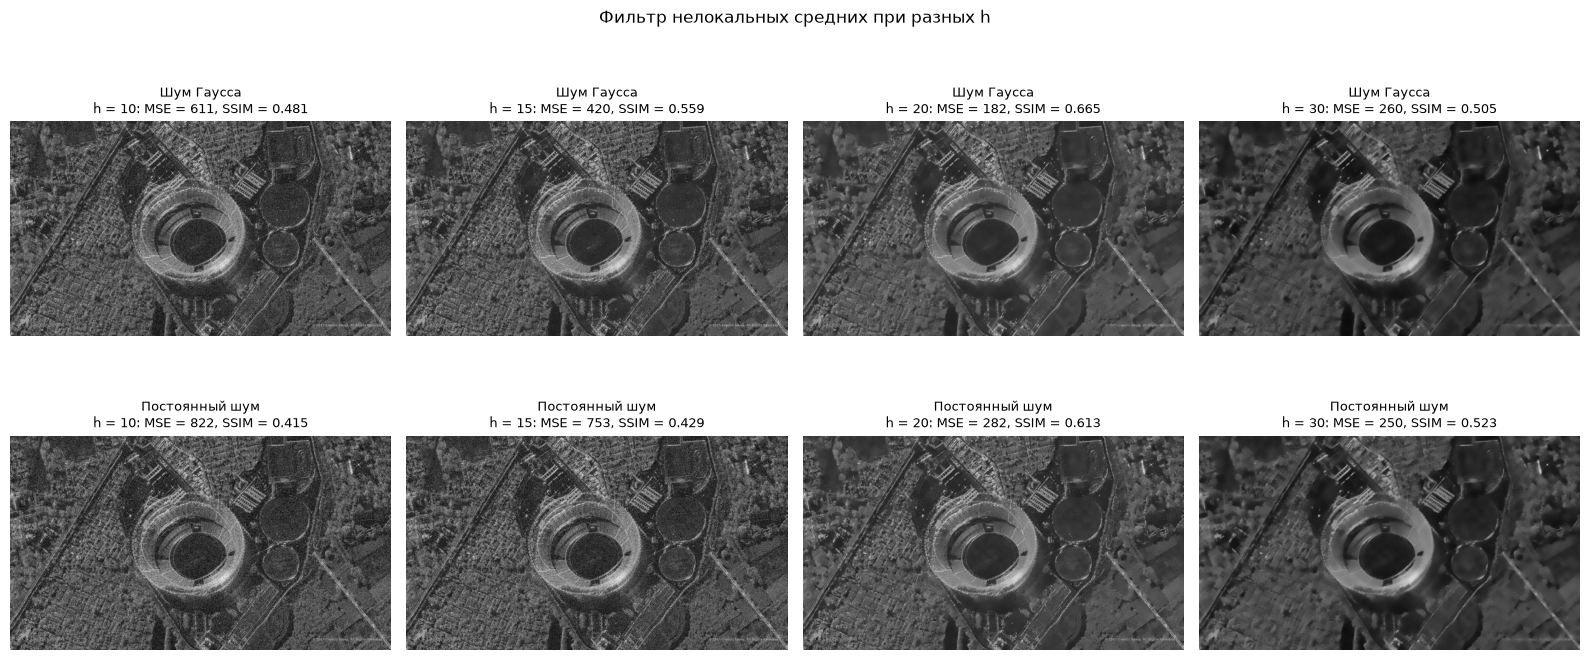

In [15]:
plot_grid(nlm_gauss, nlm_unif, 'Фильтр нелокальных средних при разных h')

## Задание 8. Итоговое сравнение фильтров

Сводим все результаты в таблицы (сортировка по SSIM) и выбираем лучший фильтр для каждого
типа шума.

In [16]:
for noise_name, noisy_ssim in [('Шум Гаусса', ssim_noise_gauss), ('Постоянный шум', ssim_noise_unif)]:
    print('=' * 22, noise_name, '(SSIM без фильтрации = %.4f)' % noisy_ssim, '=' * 22)
    rows = sorted([r for r in results if r[0] == noise_name], key=lambda r: r[3], reverse=True)
    print('%-36s %10s %8s' % ('Фильтр', 'MSE', 'SSIM'))
    for _, filter_name, mse, ssim in rows:
        print('%-36s %10.1f %8.4f' % (filter_name, mse, ssim))
    best_mse = min(rows, key=lambda r: r[2])
    best_ssim = max(rows, key=lambda r: r[3])
    print()
    print('Лучший по MSE:  %s (MSE = %.1f)' % (best_mse[1], best_mse[2]))
    print('Лучший по SSIM: %s (SSIM = %.4f)' % (best_ssim[1], best_ssim[3]))
    print()

====================== Шум Гаусса (SSIM без фильтрации = 0.4805) ======================
Фильтр                                      MSE     SSIM
Фильтр Гаусса (k = 3)                     149.7   0.7245
Фильтр Гаусса (k = 5)                     156.3   0.7066
Билатериальный (d = 5, sigma = 50)        162.6   0.7036
Нелокальных средних (h = 20)              182.1   0.6653
Фильтр Гаусса (k = 7)                     188.7   0.6480
Медианный (k = 3)                         209.6   0.6378
Билатериальный (d = 9, sigma = 75)        201.7   0.6127
Билатериальный (d = 5, sigma = 25)        302.9   0.6029
Фильтр Гаусса (k = 9)                     214.6   0.6019
Медианный (k = 5)                         240.5   0.5610
Нелокальных средних (h = 15)              420.1   0.5590
Билатериальный (d = 9, sigma = 150)       253.1   0.5281
Нелокальных средних (h = 30)              259.8   0.5047
Медианный (k = 7)                         286.3   0.4824
Нелокальных средних (h = 10)              610.5   0.4805


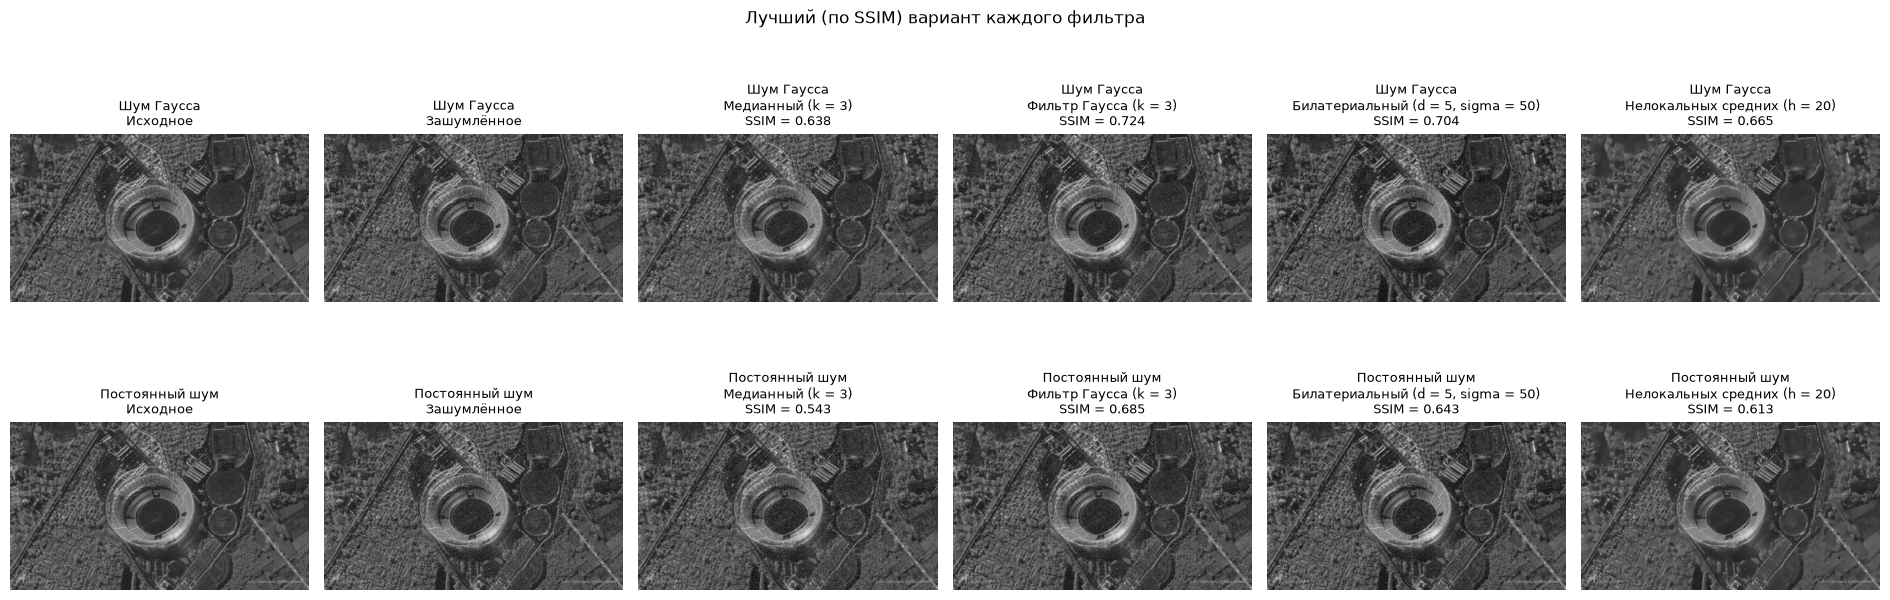

In [17]:
# лучший (по SSIM) вариант каждого фильтра для каждого типа шума
filter_groups = ['Медианный', 'Фильтр Гаусса', 'Билатериальный', 'Нелокальных средних']

plt.figure(figsize=(19, 7))
row = 0
for noise_name, noisy_img in [('Шум Гаусса', image_noise_gauss),
                              ('Постоянный шум', image_noise_unif)]:
    columns = [('Исходное', image_gray),
               ('Зашумлённое', noisy_img)]
    for group in filter_groups:
        candidates = [r for r in results if r[0] == noise_name and r[1].startswith(group)]
        best = max(candidates, key=lambda r: r[3])
        columns.append((best[1] + '\nSSIM = %.3f' % best[3], images[(noise_name, best[1])]))

    for col, (title, img) in enumerate(columns):
        plt.subplot(2, len(columns), row * len(columns) + col + 1)
        plt.imshow(img, cmap='gray')
        plt.title('%s\n%s' % (noise_name, title), fontsize=9)
        plt.axis('off')
    row += 1

plt.suptitle('Лучший (по SSIM) вариант каждого фильтра')
plt.tight_layout()
plt.show()